# 05. 모델 종합 비교

**목적**: 02~04 노트북에서 저장한 결과를 한 곳에 모아 정량·정성 비교

## 비교 대상
| 모델 | 분류 | 특징 |
|------|------|------|
| TF-IDF + LogReg | 전통적 | 베이스라인 |
| SimpleRNN | 순환 신경망 | 가장 단순한 RNN |
| LSTM | 순환 신경망 | gate로 장기 의존성 학습 |
| BiLSTM | 순환 신경망 | 양방향 + MaxPool |
| DistilBERT | Transformer | 양방향 self-attention, 사전학습 |
| GPT-2 | Transformer | 단방향(causal), 생성 모델 기반 |

### 0. Google Drive 마운트 및 경로 설정

In [1]:
# Google Drive 마운트
import os, sys

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/sentiment_analysis'
    IN_COLAB = True
except ImportError:
    # 로컬 환경에서 실행할 경우: 현재 디렉토리 기준
    PROJECT_DIR = '.'
    IN_COLAB = False
    print('로컬 환경에서 실행 중')

# 하위 폴더 정의
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# utils.py import 경로 추가
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

print(f'프로젝트 경로: {PROJECT_DIR}')
print(f'데이터 경로 : {DATA_DIR}')
print(f'결과 경로  : {RESULTS_DIR}')

Mounted at /content/drive
프로젝트 경로: /content/drive/MyDrive/sentiment_analysis
데이터 경로 : /content/drive/MyDrive/sentiment_analysis/data
결과 경로  : /content/drive/MyDrive/sentiment_analysis/results


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from utils import LABEL_NAMES, plot_confusion_matrix

sns.set_style('whitegrid')

### 1. 결과 로드 및 종합 표

In [3]:
# 각 노트북에서 저장한 JSON 로드
all_results = []

# 베이스라인
try:
    with open(os.path.join(RESULTS_DIR, 'result_baseline.json')) as f:
        all_results.append(json.load(f))
except FileNotFoundError:
    print('result_baseline.json 없음')

# RNN/LSTM/BiLSTM
try:
    with open(os.path.join(RESULTS_DIR, 'result_rnn_lstm.json')) as f:
        rnn_lstm = json.load(f)
        for name in ['SimpleRNN', 'LSTM', 'BiLSTM']:
            if name in rnn_lstm:
                all_results.append(rnn_lstm[name])
except FileNotFoundError:
    print('result_rnn_lstm.json 없음')

# BERT
try:
    with open(os.path.join(RESULTS_DIR, 'result_bert.json')) as f:
        all_results.append(json.load(f))
except FileNotFoundError:
    print('result_bert.json 없음')

# GPT
try:
    with open(os.path.join(RESULTS_DIR, 'result_gpt.json')) as f:
        all_results.append(json.load(f))
except FileNotFoundError:
    print('result_gpt.json 없음')

df_results = pd.DataFrame(all_results)
print(f'총 {len(df_results)}개 모델 결과 로드')
df_results

result_baseline.json 없음
총 5개 모델 결과 로드


,model,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,train_time_sec,num_params
0,SimpleRNN,0.404641,0.192049,0.233133,0.134880,0.333333,15.903811,NaN
1,LSTM,0.480475,0.362460,0.393348,0.363025,0.427178,227.251228,NaN
2,BiLSTM,0.726655,0.729719,0.727121,0.738541,0.724344,14.559247,NaN
3,DistilBERT,0.790323,0.793681,0.790623,0.794960,0.792549,152.292562,66955779.0
4,GPT-2,0.790606,0.793975,0.790326,0.792028,0.797170,453.002043,124442112.0


In [4]:
# 정렬용 컬럼 + 보기 좋게
cols = ['model', 'accuracy', 'f1_macro', 'f1_weighted',
        'precision_macro', 'recall_macro', 'train_time_sec']
cols = [c for c in cols if c in df_results.columns]
summary = df_results[cols].copy()
summary = summary.sort_values('f1_macro', ascending=False).reset_index(drop=True)
summary.round(4)

,model,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,train_time_sec
0,GPT-2,0.7906,0.7940,0.7903,0.7920,0.7972,453.0020
1,DistilBERT,0.7903,0.7937,0.7906,0.7950,0.7925,152.2926
2,BiLSTM,0.7267,0.7297,0.7271,0.7385,0.7243,14.5592
3,LSTM,0.4805,0.3625,0.3933,0.3630,0.4272,227.2512
4,SimpleRNN,0.4046,0.1920,0.2331,0.1349,0.3333,15.9038


### 2. 성능 비교 막대그래프

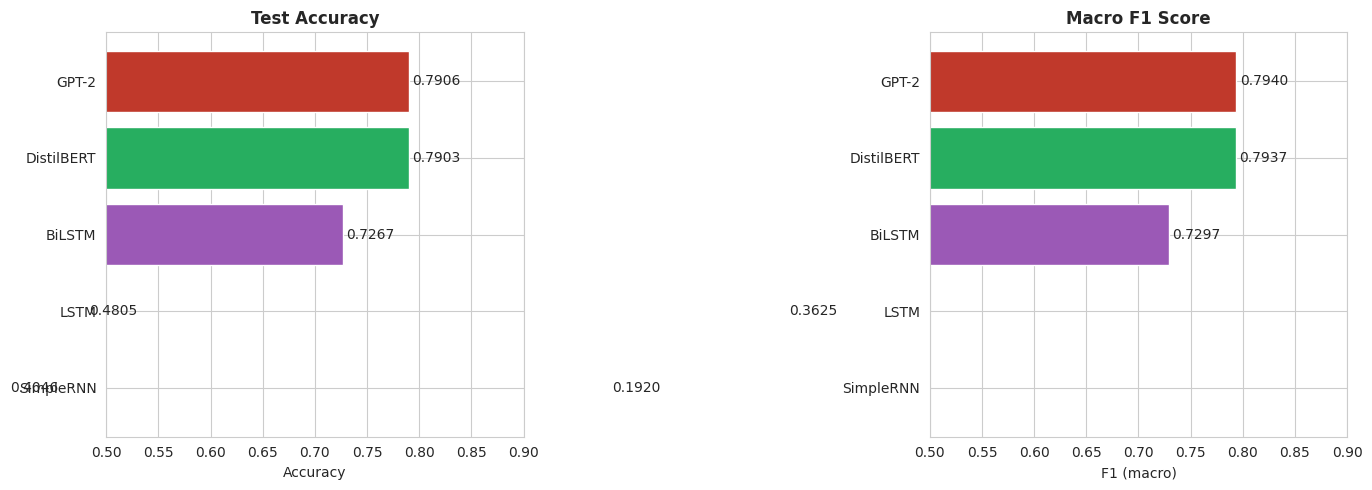

In [5]:
model_colors = {
    'TF-IDF + LogReg': '#7f8c8d',
    'SimpleRNN':       '#3498db',
    'LSTM':            '#e67e22',
    'BiLSTM':          '#9b59b6',
    'DistilBERT':      '#27ae60',
    'GPT-2':           '#c0392b',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
df_sorted = df_results.sort_values('accuracy', ascending=True)
colors = [model_colors.get(m, '#999') for m in df_sorted['model']]
axes[0].barh(df_sorted['model'], df_sorted['accuracy'], color=colors)
axes[0].set_xlabel('Accuracy'); axes[0].set_title('Test Accuracy', fontweight='bold')
axes[0].set_xlim(0.5, max(0.9, df_sorted['accuracy'].max()*1.05))
for i, v in enumerate(df_sorted['accuracy']):
    axes[0].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=10)

# F1 macro
df_sorted = df_results.sort_values('f1_macro', ascending=True)
colors = [model_colors.get(m, '#999') for m in df_sorted['model']]
axes[1].barh(df_sorted['model'], df_sorted['f1_macro'], color=colors)
axes[1].set_xlabel('F1 (macro)'); axes[1].set_title('Macro F1 Score', fontweight='bold')
axes[1].set_xlim(0.5, max(0.9, df_sorted['f1_macro'].max()*1.05))
for i, v in enumerate(df_sorted['f1_macro']):
    axes[1].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_bars.png'), dpi=120, bbox_inches='tight')
plt.show()

### 3. 성능 vs 학습 시간 (효율성)

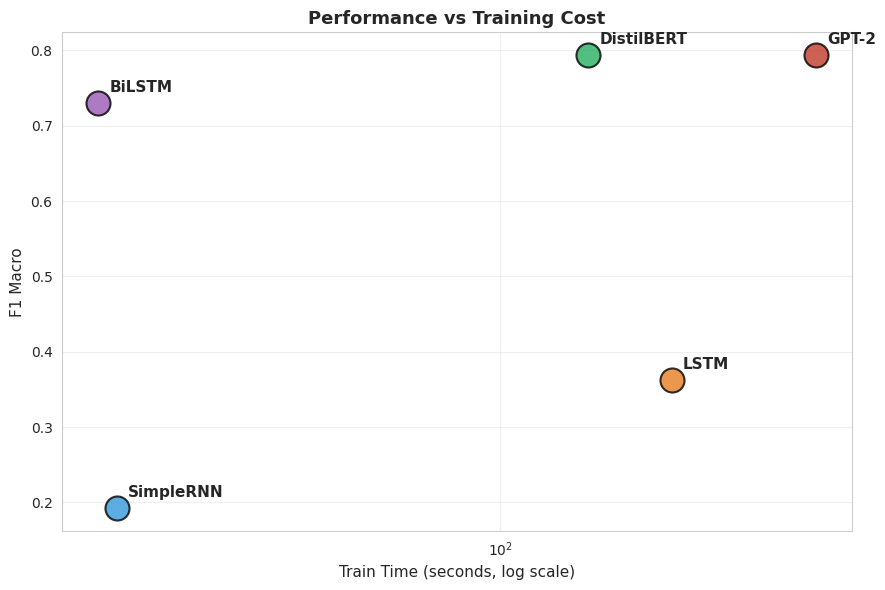

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
for _, row in df_results.iterrows():
    if pd.notna(row.get('train_time_sec')):
        c = model_colors.get(row['model'], '#999')
        ax.scatter(row['train_time_sec'], row['f1_macro'],
                   s=300, c=c, alpha=0.8, edgecolors='black', linewidths=1.5)
        ax.annotate(row['model'],
                    (row['train_time_sec'], row['f1_macro']),
                    xytext=(8, 8), textcoords='offset points',
                    fontsize=11, fontweight='bold')

ax.set_xscale('log')
ax.set_xlabel('Train Time (seconds, log scale)', fontsize=11)
ax.set_ylabel('F1 Macro', fontsize=11)
ax.set_title('Performance vs Training Cost', fontweight='bold', fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_efficiency.png'), dpi=120, bbox_inches='tight')
plt.show()

### 4. Confusion Matrix 한자리 비교

In [7]:
# 예측값 로드
preds_dict = {}

try:
    d = np.load(os.path.join(RESULTS_DIR, 'preds_rnn_lstm.npz'))
    y_test = d['y_test']
    preds_dict['SimpleRNN'] = d['pred_rnn']
    preds_dict['LSTM']      = d['pred_lstm']
    preds_dict['BiLSTM']    = d['pred_bilstm']
except FileNotFoundError:
    pass

try:
    d = np.load(os.path.join(RESULTS_DIR, 'preds_bert.npz'))
    y_test = d['y_test']
    preds_dict['DistilBERT'] = d['pred_bert']
except FileNotFoundError:
    pass

try:
    d = np.load(os.path.join(RESULTS_DIR, 'preds_gpt.npz'))
    y_test = d['y_test']
    preds_dict['GPT-2'] = d['pred_gpt']
except FileNotFoundError:
    pass

print(f'예측값 로드: {list(preds_dict.keys())}')

예측값 로드: ['SimpleRNN', 'LSTM', 'BiLSTM', 'DistilBERT', 'GPT-2']


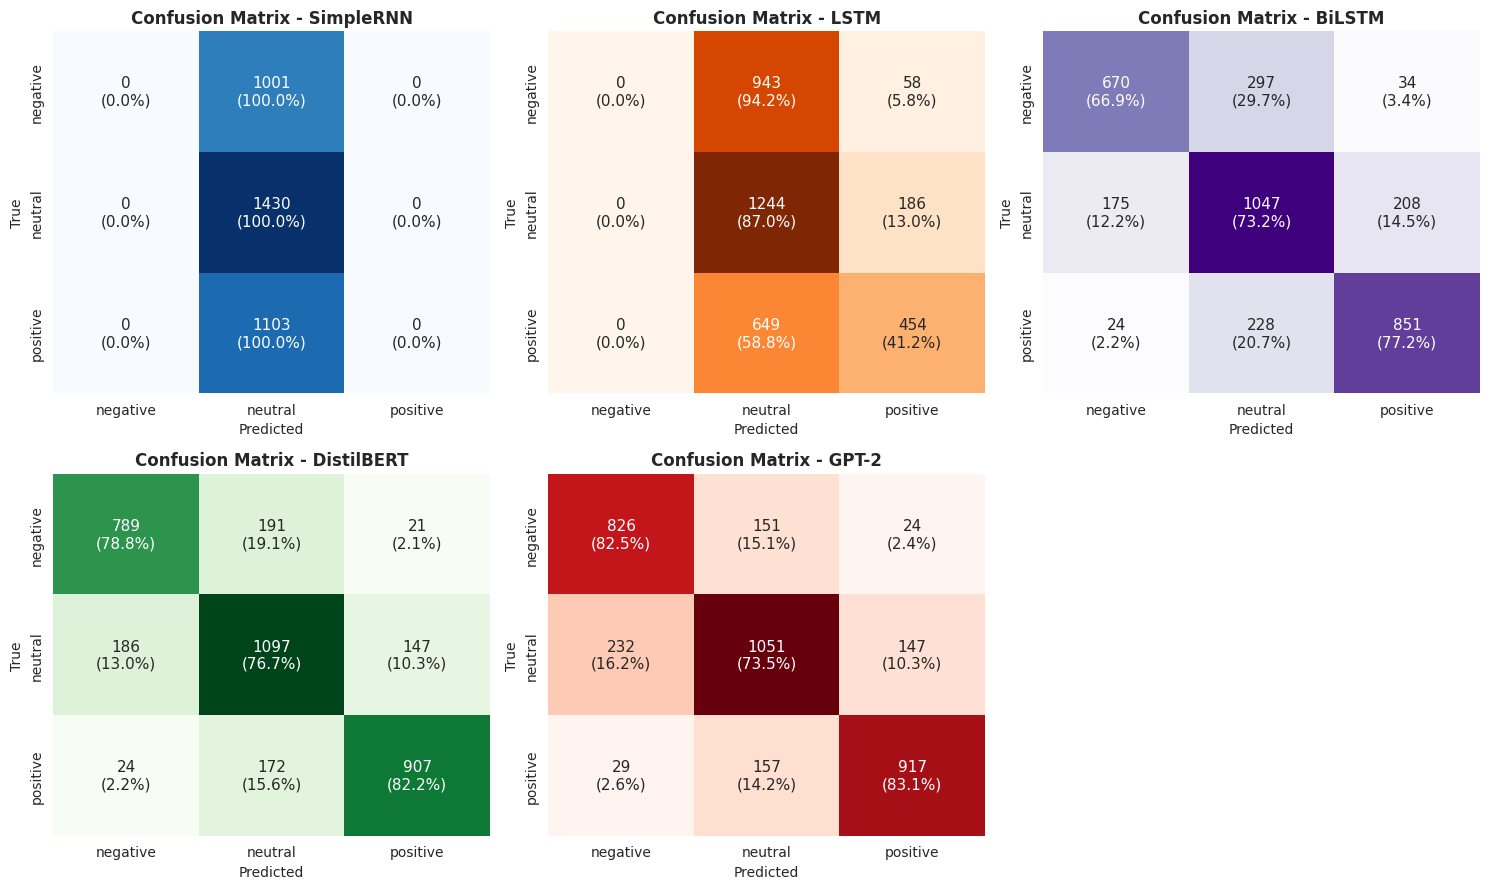

In [8]:
n = len(preds_dict)
if n > 0:
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows))
    axes = axes.flatten() if n > 1 else [axes]

    cmaps = ['Blues', 'Oranges', 'Purples', 'Greens', 'Reds', 'Greys']
    for i, (name, pred) in enumerate(preds_dict.items()):
        plot_confusion_matrix(y_test, pred, name, ax=axes[i],
                              cmap=cmaps[i % len(cmaps)])

    # 빈 subplot 숨기기
    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'comparison_confusion.png'), dpi=120, bbox_inches='tight')
    plt.show()

### 5. 클래스별 성능 비교

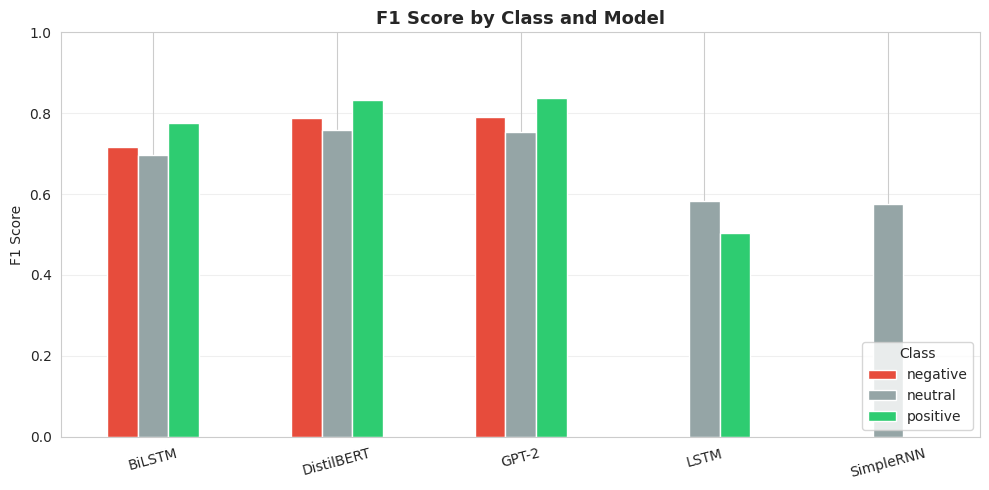


클래스별 F1 표:


class,negative,neutral,positive
model,,,
BiLSTM,0.7166,0.6975,0.7750
DistilBERT,0.7890,0.7592,0.8329
GPT-2,0.7912,0.7537,0.8371
LSTM,0.0000,0.5832,0.5042
SimpleRNN,0.0000,0.5761,0.0000


In [9]:
from sklearn.metrics import f1_score

per_class = []
for name, pred in preds_dict.items():
    f1s = f1_score(y_test, pred, average=None)
    for i, lbl in enumerate(LABEL_NAMES):
        per_class.append({'model': name, 'class': lbl, 'f1': f1s[i]})

df_pc = pd.DataFrame(per_class)
pivot = df_pc.pivot(index='model', columns='class', values='f1')
pivot = pivot[LABEL_NAMES]

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax,
           color=['#e74c3c', '#95a5a6', '#2ecc71'])
ax.set_title('F1 Score by Class and Model', fontweight='bold', fontsize=13)
ax.set_ylabel('F1 Score'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Class', loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_perclass.png'), dpi=120, bbox_inches='tight')
plt.show()

print('\n클래스별 F1 표:')
pivot.round(4)

### 6. 모델별 고유 오분류 사례 (정성 분석)

"A 모델은 맞췄지만 B 모델은 틀린 사례"를 찾아내면 모델 간 차별점이 드러난다.

In [10]:
# test 텍스트 로드
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_clean.csv'))
texts = test_df['text'].values

# 예: BiLSTM은 틀렸는데 BERT는 맞춘 경우
if 'BiLSTM' in preds_dict and 'DistilBERT' in preds_dict:
    bilstm_wrong = preds_dict['BiLSTM'] != y_test
    bert_right   = preds_dict['DistilBERT'] == y_test
    idx = np.where(bilstm_wrong & bert_right)[0]

    print(f'\n BiLSTM은 틀렸지만 BERT가 맞춘 사례: {len(idx)}개')
    print('-' * 70)
    for i in idx[:5]:
        print(f'True: {LABEL_NAMES[y_test[i]]:>8} | BiLSTM: {LABEL_NAMES[preds_dict["BiLSTM"][i]]:>8} | BERT: {LABEL_NAMES[preds_dict["DistilBERT"][i]]:>8}')
        print(f'  → {texts[i][:140]}')
        print()


 BiLSTM은 틀렸지만 BERT가 맞춘 사례: 470개
----------------------------------------------------------------------
True: positive | BiLSTM:  neutral | BERT: positive
  →  http://twitpic.com/4w75p - I like it!!

True: negative | BiLSTM:  neutral | BERT: negative
  → Cramps . . .

True:  neutral | BiLSTM: negative | BERT:  neutral
  → There is a faux gothy chick looking at me, sorry I am not going to camden and I like pop-punk and jimmy eat world

True: negative | BiLSTM:  neutral | BERT: negative
  →  4n? ma rog  never heard of it  esti beat acum? u tweet too much

True: positive | BiLSTM:  neutral | BERT: positive
  →  Hi there.  I agree!  Small children should be running about happy, not breaking down in tears



In [11]:
# BERT vs GPT 차이점
if 'DistilBERT' in preds_dict and 'GPT-2' in preds_dict:
    bert_right = preds_dict['DistilBERT'] == y_test
    gpt_wrong  = preds_dict['GPT-2']     != y_test
    idx = np.where(bert_right & gpt_wrong)[0]

    print(f'\n BERT는 맞췄지만 GPT는 틀린 사례: {len(idx)}개')
    print('-' * 70)
    for i in idx[:5]:
        print(f'True: {LABEL_NAMES[y_test[i]]:>8} | BERT: {LABEL_NAMES[preds_dict["DistilBERT"][i]]:>8} | GPT: {LABEL_NAMES[preds_dict["GPT-2"][i]]:>8}')
        print(f'  → {texts[i][:140]}')
        print()


 BERT는 맞췄지만 GPT는 틀린 사례: 228개
----------------------------------------------------------------------
True:  neutral | BERT:  neutral | GPT: negative
  →  TGIF is right...I think I broke my toe last night - on my bad foot.

True: negative | BERT: negative | GPT:  neutral
  → The underwire in my bra is sticking out and poking me in the armpit

True:  neutral | BERT:  neutral | GPT: negative
  →  I can`t call Mitch!  Im from sweden!

True:  neutral | BERT:  neutral | GPT: negative
  → was so excited to eat the wartermelon i bought the other day and it was terrible and not sweet

True: positive | BERT: positive | GPT:  neutral
  →  haaaw..well i get out of class at 10:50..i hope i make it



### 7. 최종 결과 표 저장

In [12]:
summary.to_csv(os.path.join(RESULTS_DIR, 'final_comparison.csv'), index=False)
print('final_comparison.csv 저장')
print()
print(summary.to_string(index=False))

final_comparison.csv 저장

     model  accuracy  f1_macro  f1_weighted  precision_macro  recall_macro  train_time_sec
     GPT-2  0.790606  0.793975     0.790326         0.792028      0.797170      453.002043
DistilBERT  0.790323  0.793681     0.790623         0.794960      0.792549      152.292562
    BiLSTM  0.726655  0.729719     0.727121         0.738541      0.724344       14.559247
      LSTM  0.480475  0.362460     0.393348         0.363025      0.427178      227.251228
 SimpleRNN  0.404641  0.192049     0.233133         0.134880      0.333333       15.903811
